In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [ ]:
# Importing essential sklearn modules for data preprocessing, model building, evaluation, and pipelne creation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [ ]:
# import XHBoost for boosting models

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    from sklearn.ensemble import HistGradientBoostingClassifier
    xgb_available = False

In [ ]:
# Load the data

file_path =  ("/content/TRAIN-HEALTH INSURANCE CROSS SELL PREDICTION (2) (1).csv")
df = pd.read_csv(file_path)
df.tail(20)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
381089,381090,Female,24,1,10.0,0,< 1 Year,Yes,47526.0,151.0,136,0
381090,381091,Male,47,1,35.0,1,1-2 Year,No,37589.0,124.0,144,0
381091,381092,Male,71,1,28.0,1,1-2 Year,No,43369.0,26.0,43,0
381092,381093,Male,38,1,28.0,1,1-2 Year,No,2630.0,124.0,130,0
381093,381094,Female,22,1,28.0,1,< 1 Year,No,59216.0,152.0,279,0
381094,381095,Female,47,1,20.0,0,1-2 Year,Yes,2630.0,26.0,84,0
381095,381096,Male,52,1,28.0,0,1-2 Year,Yes,38323.0,124.0,69,0
381096,381097,Female,49,1,10.0,0,1-2 Year,Yes,34541.0,26.0,44,0
381097,381098,Female,38,1,28.0,0,1-2 Year,Yes,52742.0,26.0,165,1
381098,381099,Female,68,1,33.0,0,> 2 Years,Yes,36326.0,26.0,196,0


In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist)
print("Missing value:", df.isnull().sum().sum())
df.info()
df['Response'].value_counts()

Shape: (381109, 12)
Columns: <bound method IndexOpsMixin.tolist of Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')>
Missing value: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy

Response
0    334399
1     46710
Name: count, dtype: int64

In [ ]:
# Drop Id if present
if 'id' in df.columns:
    df.drop(columns=['id'], inplace = True)


# Encoding categorical variables
df['Gender'] = df['Gender'].map({'male':1, 'Female':0})
df['vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes':1, 'No':0})
df['Vehicle_Age'] = df['Vehicle_Age'].map({'<1 Year':0, '1-2 Year':1, '<2 Years':2})

# Converting float to int where needed
df['Region_Code'] = df['Region_Code'].astype(int)
df['Policy_Sales_Channel'] = df['Policy_Sales_Channel'].astype(int)
df.head(10)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,vehicle_Damage
0,NaN,44,1,28,0,NaN,Yes,40454.0,26,217,1,1
1,NaN,76,1,3,0,1.0,No,33536.0,26,183,0,0
2,NaN,47,1,28,0,NaN,Yes,38294.0,26,27,1,1
3,NaN,21,1,11,1,NaN,No,28619.0,152,203,0,0
4,0.0,29,1,41,1,NaN,No,27496.0,152,39,0,0
5,0.0,24,1,33,0,NaN,Yes,2630.0,160,176,0,1
6,NaN,23,1,11,0,NaN,Yes,23367.0,152,249,0,1
7,0.0,56,1,28,0,1.0,Yes,32031.0,26,72,1,1
8,0.0,24,1,3,1,NaN,No,27619.0,152,28,0,0
9,0.0,32,1,6,1,NaN,No,28771.0,152,80,0,0


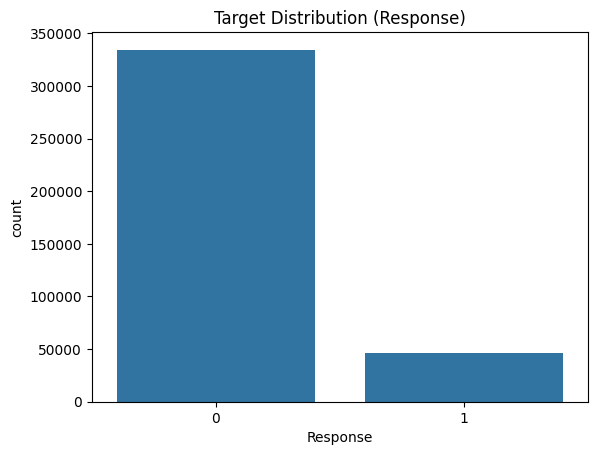

In [ ]:
# Target distribution
sns.countplot(x='Response', data=df)
plt.title('Target Distribution (Response)')
plt.show()

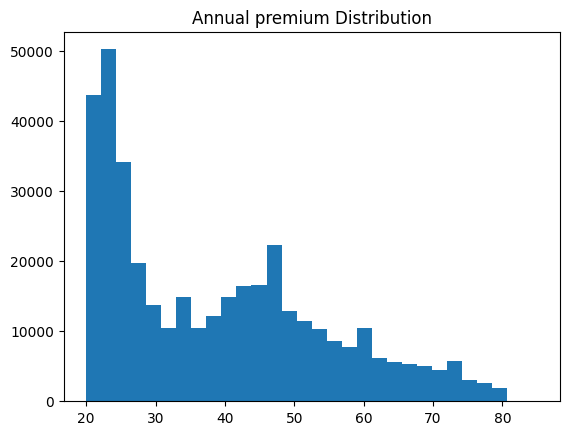

In [ ]:
# Age distribution
plt.hist(df['Age'], bins = 30)
plt.title('Annual premium Distribution')
plt.show()

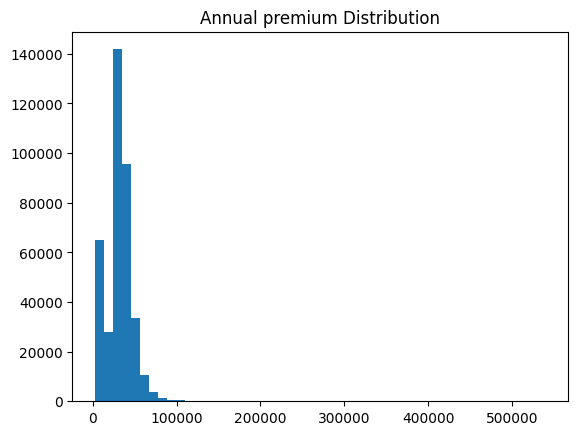

In [ ]:
# Annual premium Distribution
plt.hist(df['Annual_Premium'], bins = 50)
plt.title('Annual premium Distribution')
plt.show()

In [ ]:
# Display average response rate for each category in Gender, Vehicle_Age, Vehicle_Damage

for col in ['Gender', 'Vehicle_Age','Vehicle_Damage']:
    rate = df.groupby(col)['Response'].mean()
    print(f"Response Rate by {col}:\n", rate, "\n")

Response Rate by Gender:
 Gender
0.0    0.103902
Name: Response, dtype: float64 

Response Rate by Vehicle_Age:
 Vehicle_Age
1.0    0.173755
Name: Response, dtype: float64 

Response Rate by Vehicle_Damage:
 Vehicle_Damage
No     0.005204
Yes    0.237655
Name: Response, dtype: float64 



In [ ]:
# Split the dataset into training and testing sets with stratified sampling to maintain class balance

X = df.drop(columns=['Response'])
y = df['Response']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Train shape:", X_train.shape, "Test shape", X_test.shape)

Train shape: (266776, 11) Test shape (114333, 11)


In [ ]:
# Scaling continuous features
num_features = ['Age','Annual_Premium','Vintage']
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_features)],remainder='passthrough')
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((266776, 11), (114333, 11))

In [ ]:


# Encode categorical features automatically.
X = df.drop(['id', 'Response'], axis=1)
y = df['Response']

# Convert all categorical text columns into numerical form
X = pd.get_dummies(X, drop_first=True)

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Scale numeric data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define Models ---
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

if xgb_available:
    models['XGBoost'] = XGBClassifier(
        use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1
    )
else:
    models['HistGB'] = HistGradientBoostingClassifier(random_state=42)

# --- Train & Evaluate Models ---
result = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...", flush=True)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print(f" Accuracy: {acc:.4f}, ROC-AUC: {roc:.4f}", flush=True)
    print(classification_report(y_test, y_pred), flush=True)

    result[name] = {'model': model, 'accuracy': acc, 'roc_auc': roc}


🔹 Training LogisticRegression...
 Accuracy: 0.8751, ROC-AUC: 0.8401
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       1.00      0.00      0.00      9523

    accuracy                           0.88     76222
   macro avg       0.94      0.50      0.47     76222
weighted avg       0.89      0.88      0.82     76222


🔹 Training RandomForest...
 Accuracy: 0.8656, ROC-AUC: 0.8392
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     66699
           1       0.38      0.12      0.18      9523

    accuracy                           0.87     76222
   macro avg       0.63      0.55      0.55     76222
weighted avg       0.82      0.87      0.83     76222


🔹 Training HistGB...
 Accuracy: 0.8748, ROC-AUC: 0.8600
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.35      0.00      0.00     

In [ ]:
# Encode, split, and scale data for model training.
data = df.drop(columns=['id'])
data_encoded = pd.get_dummies(data, drop_first=True)
X = data_encoded.drop('Response', axis=1)
y = data_encoded['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define ML models for classification.
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

if xgb_available:
    models['XGBoost'] = XGBClassifier(
        use_label_encoder = False, eval_metric = 'logloss', random_state = 42, n_jobs=-1
    )
else:
    models['HistGB'] = HistGradientBoostingClassifier(random_state=42)

result = {}

for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1] if hasattr(model,"predict_proba") else y_pred

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    print(f" Accuracy: {acc:.4f}, ROC-AUC: {roc:.4f}")
    print(classification_report(y_test, y_pred))


    result[name] = {'model': model, 'accuracy': acc, 'roc_auc': roc}


 Training LogisticRegression...
 Accuracy: 0.8774, ROC-AUC: 0.5000
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.50      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.69      0.50      0.47     76222
weighted avg       0.83      0.88      0.82     76222


 Training RandomForest...
 Accuracy: 0.8665, ROC-AUC: 0.5455
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     66880
           1       0.36      0.12      0.18      9342

    accuracy                           0.87     76222
   macro avg       0.63      0.55      0.55     76222
weighted avg       0.82      0.87      0.84     76222


 Training HistGB...
 Accuracy: 0.8774, ROC-AUC: 0.5009
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.46      0.00      0.00      93

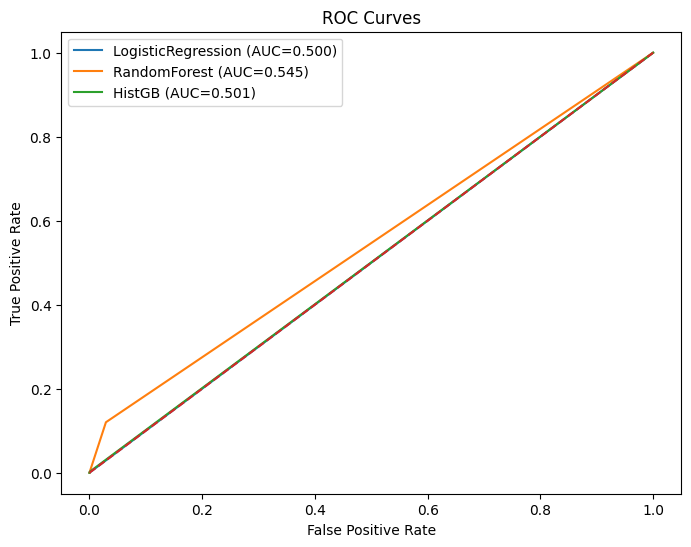

In [ ]:
# Plot ROC curves for all trained models to compare their AUC performance visually
plt.figure(figsize=(8,6))
for name, res in result.items():
    model = res['model']
    y_proba = model.predict_proba(X_test_scaled)[:,1] if hasattr(model,"predict_probs") else model.predict(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

%matplotlib inline

                 Feature  Importance
0                     id    0.210257
7                Vintage    0.192648
5         Annual_Premium    0.172602
1                    Age    0.125590
3            Region_Code    0.087721
11    Vehicle_Damage_Yes    0.063947
4     Previously_Insured    0.058346
6   Policy_Sales_Channel    0.057201
9   Vehicle_Age_< 1 Year    0.014617
8            Gender_Male    0.011363


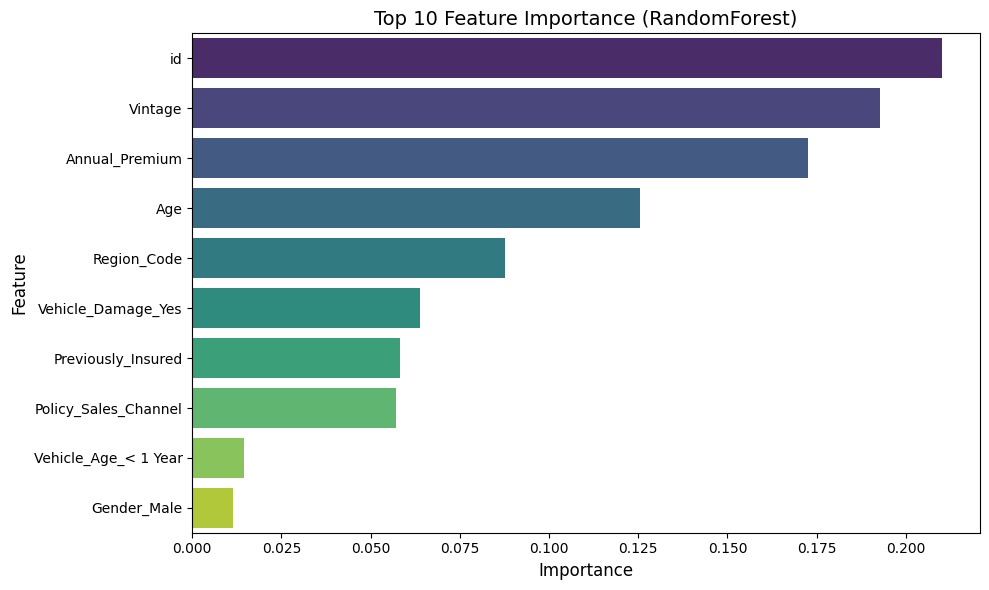

In [ ]:
# Train RandomForest and plot top 10 feature importances
X = df.drop(columns=['Response'])
y = df['Response']

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feature = X.columns

feat_imp = pd.DataFrame({'Feature': feature, 'Importance': importances })
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Feature Importance (RandomForest)", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# multiple ML models for training and comparison

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

if xgb_available:
    models['XGBoost'] = XGBClassifier(
        use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1
    )
else:
    models['HistGB'] = HistGradientBoostingClassifier(random_state=42)

# Train & Evaluate Models
result = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...", flush=True)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print(f" Accuracy: {acc:.4f}, ROC-AUC: {roc:.4f}", flush=True)
    print(classification_report(y_test, y_pred), flush=True)

    result[name] = {'model': model, 'accuracy': acc, 'roc_auc': roc}
best_model_name = max(result, key=lambda x: result[x]['roc_auc'])
best_model = result[best_model_name]['model']
# save the best trained model and its scaler to 'best_mode.pkl' for later use
import pickle
with open("best_model.pkl", "wb") as f:
    pickle.dump({'model': best_model, 'scaler': scaler}, f)

print(f"\n Best model: {best_model_name}")
print(" Best model saved as best_model.pkl")


🔹 Training LogisticRegression...
 Accuracy: 0.8751, ROC-AUC: 0.5061
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.00      0.00      0.00      9523

    accuracy                           0.88     76222
   macro avg       0.44      0.50      0.47     76222
weighted avg       0.77      0.88      0.82     76222


🔹 Training RandomForest...
 Accuracy: 0.8731, ROC-AUC: 0.5064
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.15      0.00      0.01      9523

    accuracy                           0.87     76222
   macro avg       0.51      0.50      0.47     76222
weighted avg       0.78      0.87      0.82     76222


🔹 Training HistGB...
 Accuracy: 0.8751, ROC-AUC: 0.4956
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.00      0.00      0.00     